# Wilcoxon Signed-Rank Test 

In [47]:
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon, norm

In [48]:
df_raw = pd.read_csv('data_CBR-RAG_2026-04-06_13-14_final.csv', encoding='utf-16', sep='\t')
df_raw = df_raw.copy()
df_raw['participant_id'] = df_raw['CASE']

RAG_COLS = ['Q101','Q104','Q105','Q123','Q109','Q112','Q113','Q116',
            'Q117','Q120','Q121','Q136','Q137','Q140','Q141','Q144','Q145','Q148']

LLM_COLS = ['Q102','Q103','Q106','Q108','Q110','Q111','Q114','Q115',
            'Q118','Q119','Q122','Q135','Q138','Q139','Q142','Q143','Q146','Q147']

DIMENSIONS = {
    '01': 'helpfulness',
    '02': 'clarity',
    '03': 'naturalness',
    '04': 'length appropriateness',
    '05': 'trustworthiness',
    '06': 'process grounding'
}

QUESTION_NUMBERS = list(range(1, 19))
print(f'Loaded {len(df_raw)} participants')

Loaded 36 participants


In [49]:
records = []
for i, q_num in enumerate(QUESTION_NUMBERS):
    for suffix, dim_name in DIMENSIONS.items():
        rag_col = f'{RAG_COLS[i]}_{suffix}'
        llm_col = f'{LLM_COLS[i]}_{suffix}'
        for _, row in df_raw.iterrows():
            if rag_col in df_raw.columns:
                records.append({'participant_id': row['participant_id'], 'question': q_num,
                                 'dimension': dim_name, 'system': 'CBR-RAG',
                                 'score': 6 - row[rag_col]})
            if llm_col in df_raw.columns:
                records.append({'participant_id': row['participant_id'], 'question': q_num,
                                 'dimension': dim_name, 'system': 'LLM',
                                 'score': 6 - row[llm_col]})

df_long = pd.DataFrame(records)
print(f'Total rows: {len(df_long)}')
df_long.head(6)

Total rows: 7776


,participant_id,question,dimension,system,score
0,115,1,helpfulness,CBR-RAG,2
1,115,1,helpfulness,LLM,4
2,121,1,helpfulness,CBR-RAG,3
3,121,1,helpfulness,LLM,5
4,128,1,helpfulness,CBR-RAG,5
5,128,1,helpfulness,LLM,3


## Aggregate Scores per Participant per Dimension


In [50]:
aggregated = {}
for dim in DIMENSIONS.values():
    rag_vals = (df_long[(df_long['dimension'] == dim) & (df_long['system'] == 'CBR-RAG')]
                .groupby('participant_id')['score'].mean().sort_index().values)
    llm_vals = (df_long[(df_long['dimension'] == dim) & (df_long['system'] == 'LLM')]
                .groupby('participant_id')['score'].mean().sort_index().values)
    aggregated[dim] = {'CBR-RAG': rag_vals, 'LLM': llm_vals}

## One-Sided Wilcoxon Signed-Rank Test per Dimension


In [51]:
results = []

for dim in DIMENSIONS.values():
    rag_vals = aggregated[dim]['CBR-RAG']
    llm_vals = aggregated[dim]['LLM']

    # One-sided Wilcoxon: tests if CBR-RAG > LLM
    W, p = wilcoxon(rag_vals, llm_vals, alternative='greater')

    # Effect size r = Z / sqrt(N)
    z = norm.ppf(1 - p)
    r = round(z / np.sqrt(len(rag_vals)), 3)

    # Significance across three alpha levels
    if p < 0.001:
        sig = '***'
    elif p < 0.01:
        sig = '**'
    elif p < 0.05:
        sig = '*'
    else:
        sig = ''

    results.append({
        'Dimension':   dim,
        'T':           W,
        'p-value':     round(p, 4),
        'r':           r,
        'Sig.':        sig,
    })

df_results = pd.DataFrame(results)
df_results

,Dimension,T,p-value,r,Sig.
0,helpfulness,245.5,0.6353,-0.058,
1,clarity,398.0,0.0061,0.418,**
2,naturalness,273.0,0.6625,-0.070,
3,length appropriateness,363.5,0.1294,0.188,
4,trustworthiness,354.0,0.3707,0.055,
5,process grounding,527.5,0.0000,0.736,***


## Summary Table


In [52]:
summary = df_results[['Dimension','T', 'p-value', 'r', 'Sig.']].copy()
summary = summary.sort_values('p-value').reset_index(drop=True)

print('Wilcoxon Signed-Rank Test Results')
print('=' * 75)
print(summary.to_string(index=False))
print()
print('Significance: *** p<0.001  ** p<0.01  * p<0.05')
print('Effect size r: small>=0.1  medium>=0.3  large>=0.5')

summary.to_csv('wilcoxon_onesided_results.csv', index=False)

Wilcoxon Signed-Rank Test Results
             Dimension     T  p-value      r Sig.
     process grounding 527.5   0.0000  0.736  ***
               clarity 398.0   0.0061  0.418   **
length appropriateness 363.5   0.1294  0.188     
       trustworthiness 354.0   0.3707  0.055     
           helpfulness 245.5   0.6353 -0.058     
           naturalness 273.0   0.6625 -0.070     

Significance: *** p<0.001  ** p<0.01  * p<0.05
Effect size r: small>=0.1  medium>=0.3  large>=0.5


In [53]:
import sys
!{sys.executable} -m pip install matplotlib


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


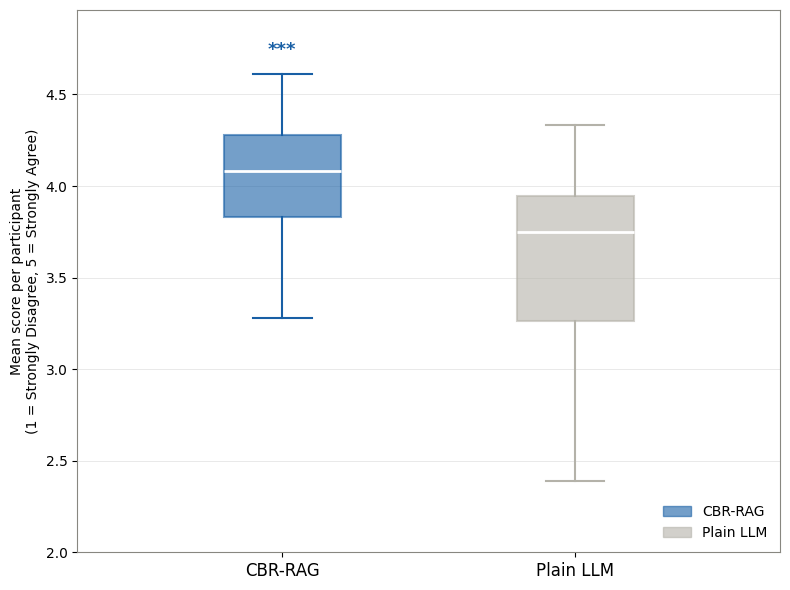

Saved boxplot_process_grounding.png


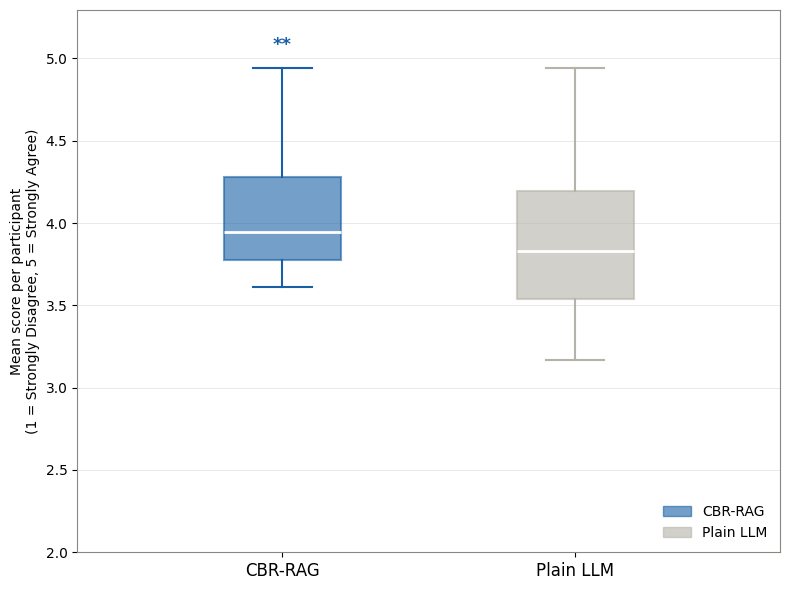

Saved boxplot_clarity.png


In [54]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

plot_dims = ['process grounding', 'clarity']
results_map = {r['Dimension']: r for r in results}

colors = {'CBR-RAG': '#185FA5', 'LLM': '#B4B2A9'}

for dim in plot_dims:
    fig, ax = plt.subplots(figsize=(8, 6))

    rag_vals = aggregated[dim]['CBR-RAG']
    llm_vals = aggregated[dim]['LLM']

    bp = ax.boxplot(
        [rag_vals, llm_vals],
        patch_artist=True,
        widths=0.4,
        showfliers=False,
        medianprops=dict(color='white', linewidth=2),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
        boxprops=dict(linewidth=1.5),
        flierprops=dict(marker='o', markersize=4, linestyle='none')
    )

    for patch, color in zip(bp['boxes'], [colors['CBR-RAG'], colors['LLM']]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
        patch.set_edgecolor(color)

    for whisker, color in zip(bp['whiskers'], [colors['CBR-RAG'], colors['CBR-RAG'],
                                                colors['LLM'], colors['LLM']]):
        whisker.set_color(color)

    for cap, color in zip(bp['caps'], [colors['CBR-RAG'], colors['CBR-RAG'],
                                        colors['LLM'], colors['LLM']]):
        cap.set_color(color)

    for flier, color in zip(bp['fliers'], [colors['CBR-RAG'], colors['LLM']]):
        flier.set_markerfacecolor(color)
        flier.set_markeredgecolor(color)

    # Calculate whisker tops manually for precise star placement
    rag_q3 = np.percentile(rag_vals, 75)
    llm_q3 = np.percentile(llm_vals, 75)
    rag_iqr = rag_q3 - np.percentile(rag_vals, 25)
    llm_iqr = llm_q3 - np.percentile(llm_vals, 25)
    rag_whisker_top = min(rag_vals.max(), rag_q3 + 1.5 * rag_iqr)
    llm_whisker_top = min(llm_vals.max(), llm_q3 + 1.5 * llm_iqr)
    y_top = max(rag_whisker_top, llm_whisker_top)

    # Dynamic y-axis — just enough room above the star
    ax.set_ylim(2.0, y_top + 0.35)

    # Significance marker just above highest whisker
    res = results_map[dim]
    sig = res['Sig.']
    ax.text(1, y_top + 0.08, sig,
        ha='center', va='bottom',
        fontsize=13, fontweight='bold', color='#185FA5')

    ax.set_xticks([1, 2])
    ax.set_xticklabels(['CBR-RAG', 'Plain LLM'], fontsize=12)
    ax.set_ylabel('Mean score per participant\n(1 = Strongly Disagree, 5 = Strongly Agree)',
                  fontsize=10)
    ax.set_xlim(0.3, 2.7)
    ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))

    # Full box frame
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_color('#888780')

    ax.grid(axis='y', linewidth=0.5, alpha=0.4)

    rag_patch = mpatches.Patch(facecolor=colors['CBR-RAG'], alpha=0.6,
                                edgecolor=colors['CBR-RAG'], label='CBR-RAG')
    llm_patch = mpatches.Patch(facecolor=colors['LLM'], alpha=0.6,
                                edgecolor=colors['LLM'], label='Plain LLM')
    ax.legend(handles=[rag_patch, llm_patch], loc='lower right',
              fontsize=10, frameon=False)

    filename = f"boxplot_{dim.lower().replace(' ', '_')}.png"
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved {filename}')